# Predicting Consumer Purchase Intentions Using Multi-Channel Behavioural Data
### Exploratory Data Analysis (EDA)


## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

## 2. Load Dataset

In [ ]:
df = pd.read_csv('/Users/Desktop/online_shoppers_intention.csv')
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Dataset Overview

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [13]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


## 4. Data Quality Check

### 4.1 Missing Values

In [14]:
missing = df.isnull().sum().reset_index()
missing.columns = ['Feature', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
print(missing[missing['Missing Count'] > 0].to_string(index=False) if missing['Missing Count'].sum() > 0 else 'No missing values found.')

No missing values found.


### 4.2 Duplicate Records

In [15]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 125


### 4.3 Data Types Summary

In [16]:
dtype_df = pd.DataFrame({'Feature': df.columns, 'Data Type': df.dtypes.values, 'Unique Values': df.nunique().values})
dtype_df.reset_index(drop=True, inplace=True)
dtype_df

,Feature,Data Type,Unique Values
0,Administrative,int64,27
1,Administrative_Duration,float64,3335
2,Informational,int64,17
3,Informational_Duration,float64,1258
4,ProductRelated,int64,311
5,ProductRelated_Duration,float64,9551
6,BounceRates,float64,1872
7,ExitRates,float64,4777
8,PageValues,float64,2704
9,SpecialDay,float64,6


## 5. Target Variable Analysis — Revenue (Purchase Intention)

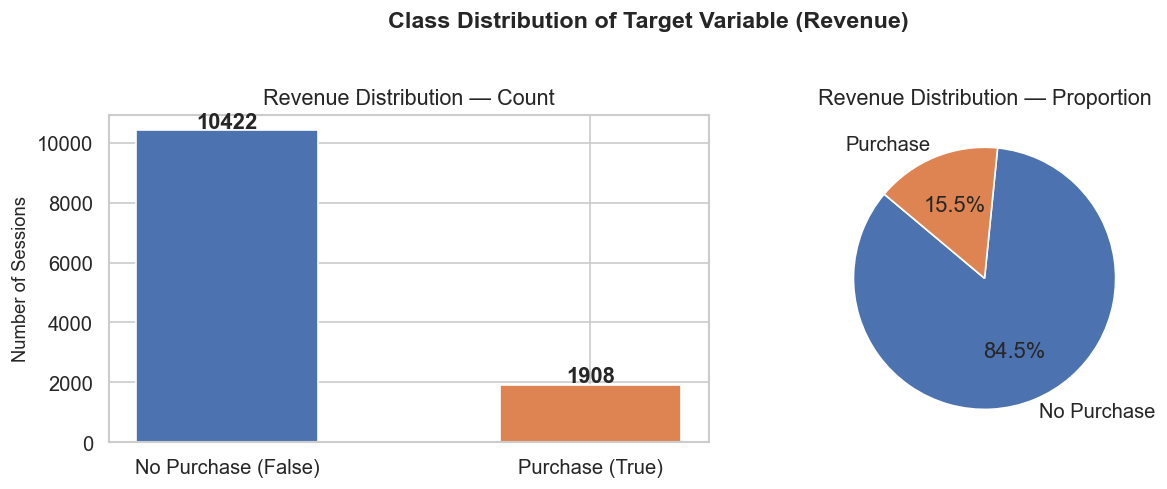

Purchase Sessions  : 1,908  (15.5%)
Non-Purchase Sessions: 10,422 (84.5%)
Class Imbalance Ratio: 1 : 5.5


In [17]:
revenue_counts = df['Revenue'].value_counts()
revenue_pct = df['Revenue'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Purchase (False)', 'Purchase (True)'], revenue_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(revenue_counts.values):
    axes[0].text(i, v + 80, str(v), ha='center', fontweight='bold')
axes[0].set_title('Revenue Distribution — Count')
axes[0].set_ylabel('Number of Sessions')

axes[1].pie(revenue_counts.values, labels=['No Purchase', 'Purchase'], autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Revenue Distribution — Proportion')

plt.suptitle('Class Distribution of Target Variable (Revenue)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Purchase Sessions  : {revenue_counts[True]:,}  ({revenue_pct[True]:.1f}%)")
print(f"Non-Purchase Sessions: {revenue_counts[False]:,} ({revenue_pct[False]:.1f}%)")
print(f"Class Imbalance Ratio: 1 : {revenue_counts[False]/revenue_counts[True]:.1f}")

## 6. Univariate Analysis

### 6.1 Numerical Features — Distribution

IndexError: index 12 is out of bounds for axis 0 with size 12

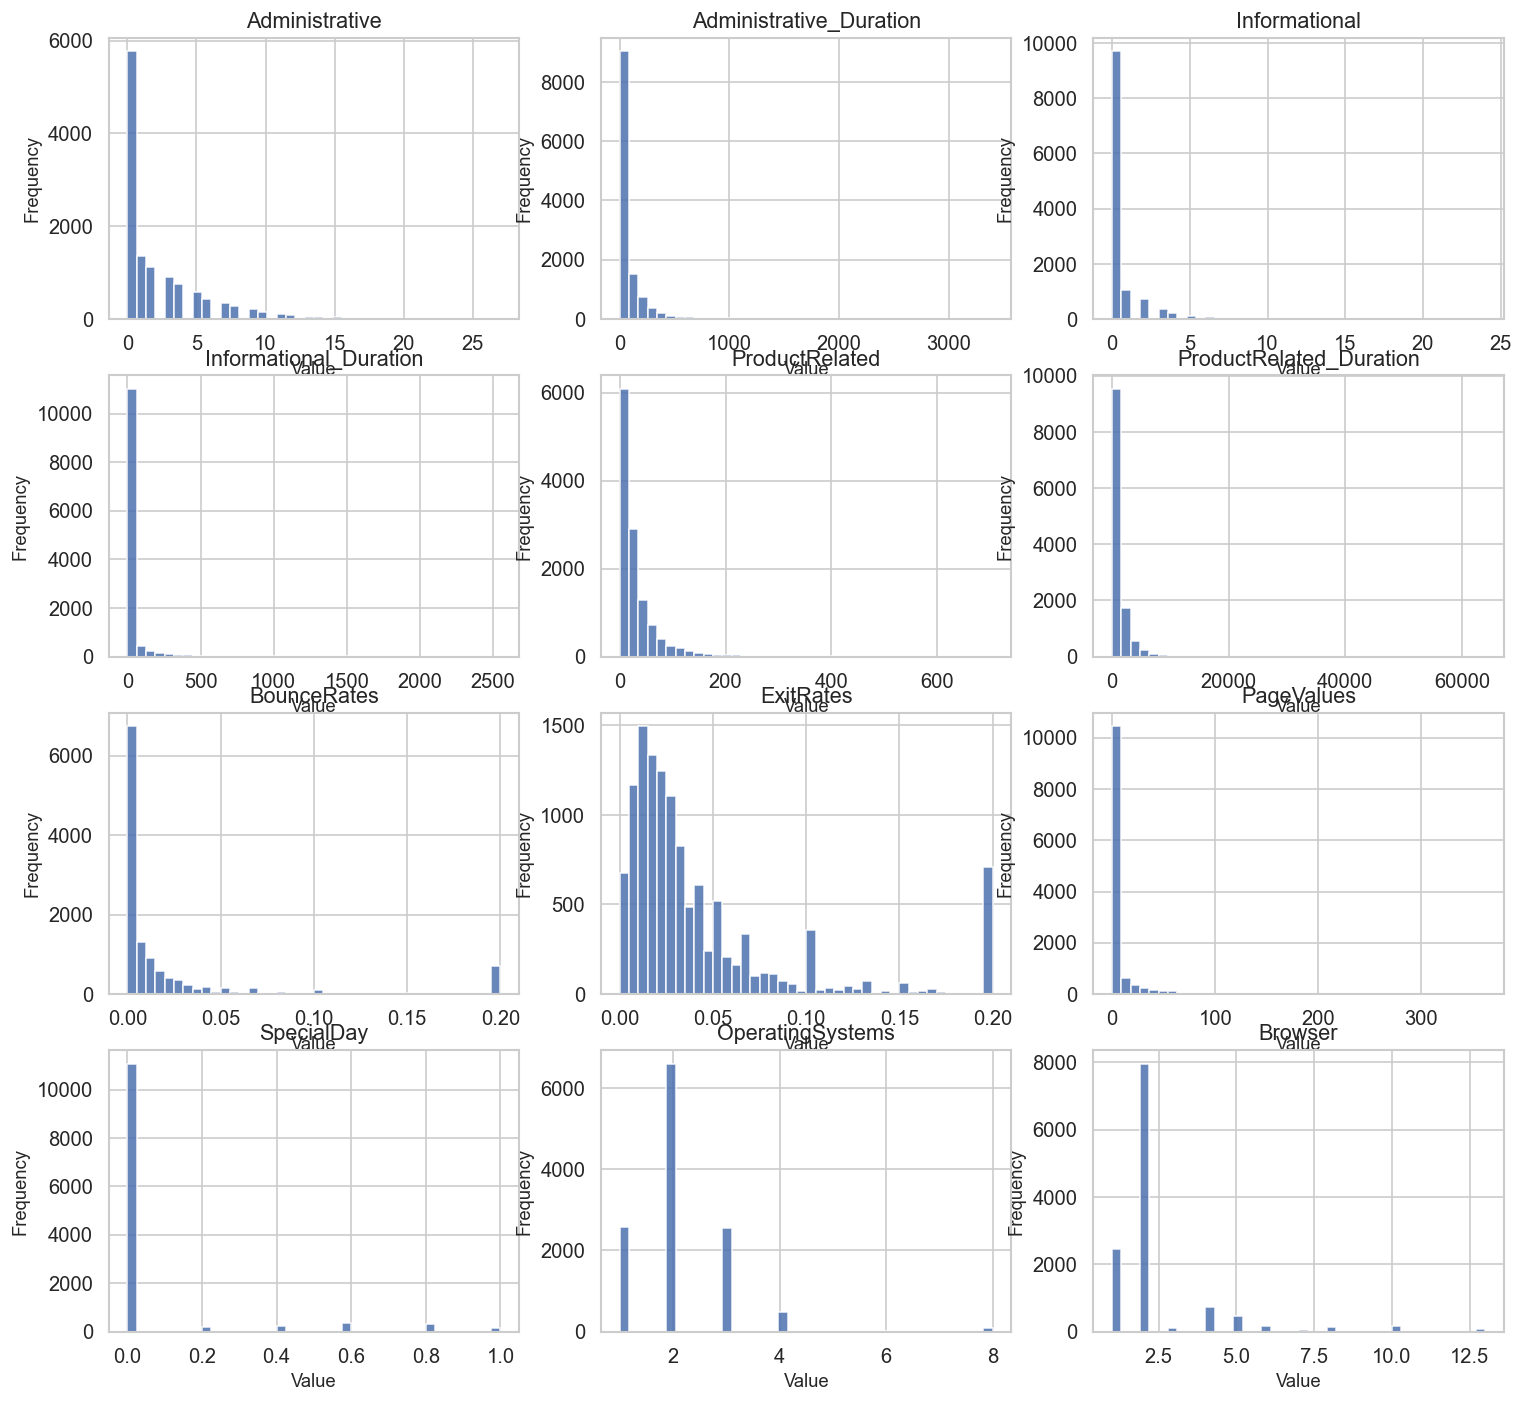

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Categorical Features — Value Counts

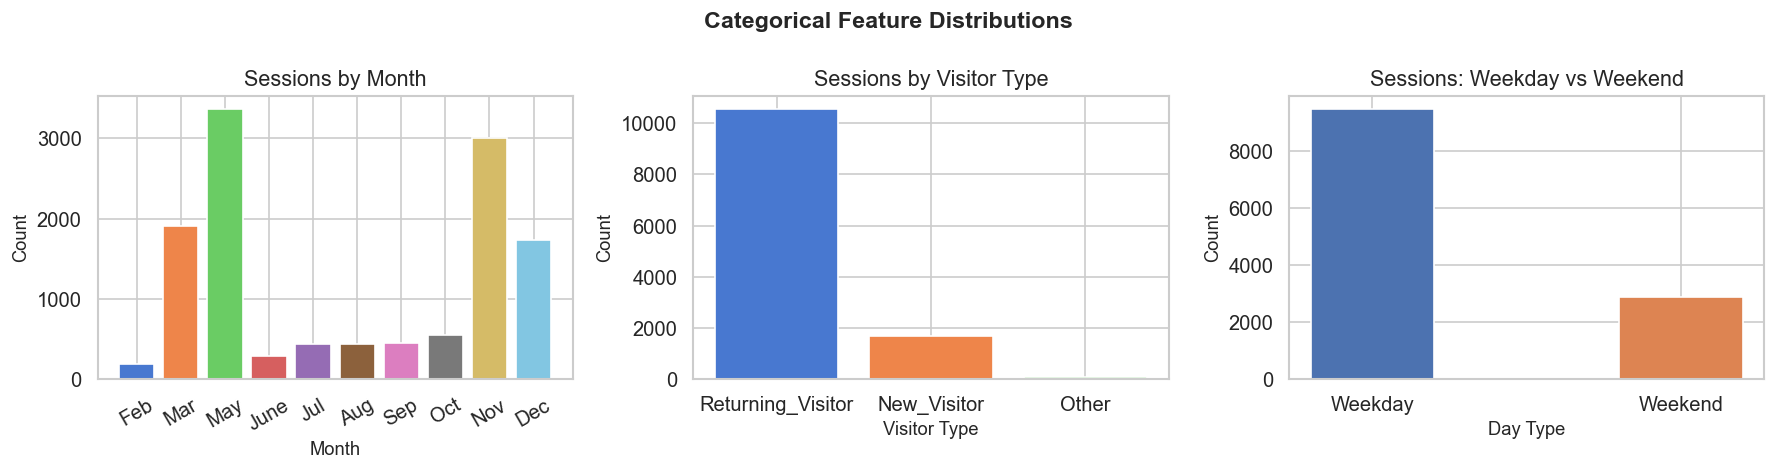

In [19]:
cat_cols = ['Month', 'VisitorType', 'Weekend']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_present = [m for m in month_order if m in df['Month'].unique()]

month_counts = df['Month'].value_counts().reindex(month_present)
axes[0].bar(month_counts.index, month_counts.values, color=sns.color_palette('muted', len(month_counts)), edgecolor='white')
axes[0].set_title('Sessions by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

vt_counts = df['VisitorType'].value_counts()
axes[1].bar(vt_counts.index, vt_counts.values, color=sns.color_palette('muted', len(vt_counts)), edgecolor='white')
axes[1].set_title('Sessions by Visitor Type')
axes[1].set_xlabel('Visitor Type')
axes[1].set_ylabel('Count')

we_counts = df['Weekend'].value_counts()
axes[2].bar(['Weekday', 'Weekend'], we_counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
axes[2].set_title('Sessions: Weekday vs Weekend')
axes[2].set_xlabel('Day Type')
axes[2].set_ylabel('Count')

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

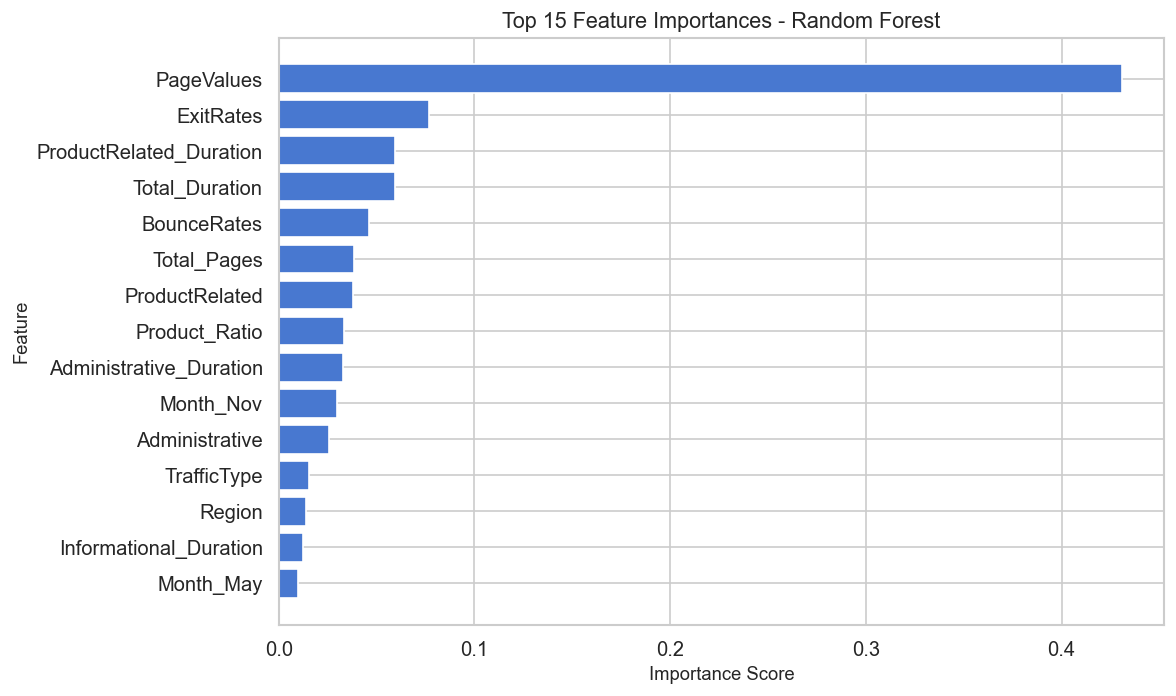

In [ ]:
top_15 = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'][::-1], top_15['Importance'][::-1])
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

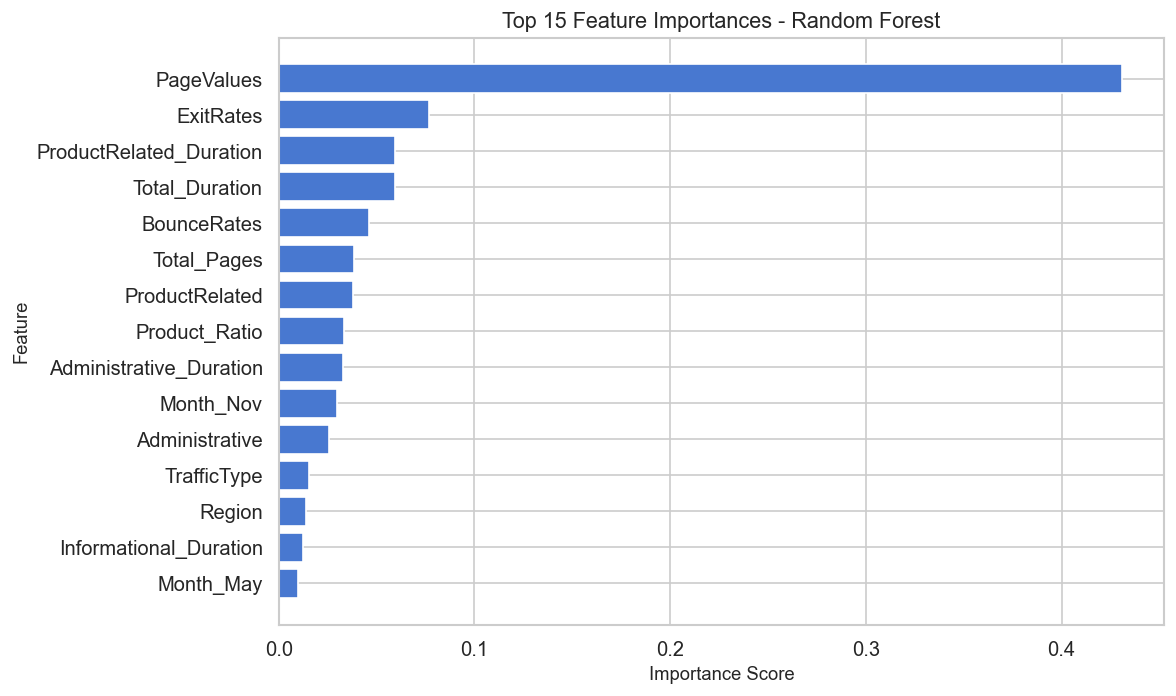

In [ ]:
top_15 = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'][::-1], top_15['Importance'][::-1])
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis — Features vs Target (Revenue)

### 7.1 Purchase Rate by Month

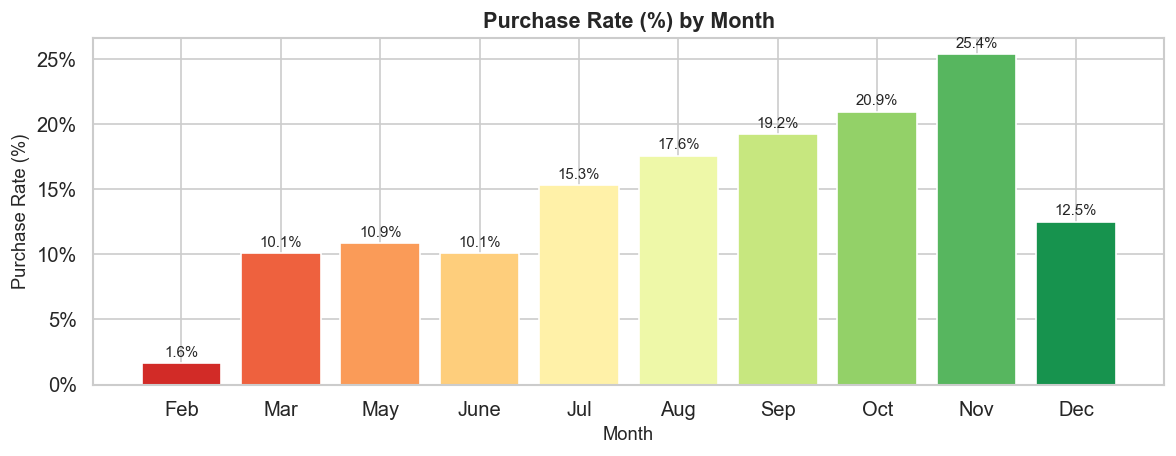

In [20]:
month_revenue = df.groupby('Month')['Revenue'].mean().reindex(month_present) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(month_revenue.index, month_revenue.values, color=sns.color_palette('RdYlGn', len(month_revenue)), edgecolor='white')
for bar, val in zip(bars, month_revenue.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Purchase Rate (%) by Month', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Purchase Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

### 7.2 Purchase Rate by Visitor Type and Weekend

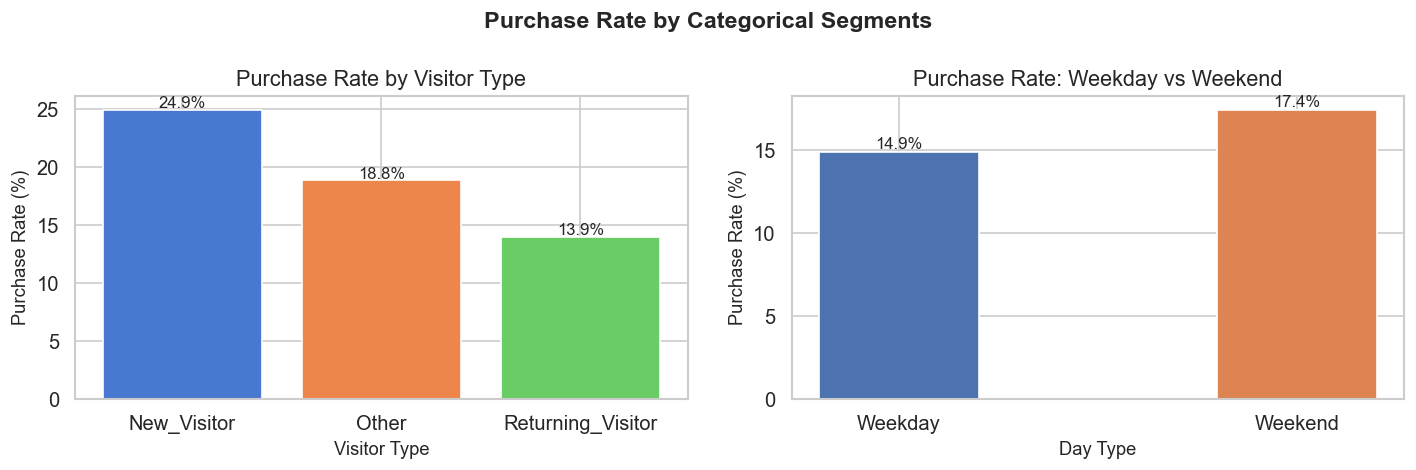

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vt_rate = df.groupby('VisitorType')['Revenue'].mean() * 100
axes[0].bar(vt_rate.index, vt_rate.values, color=sns.color_palette('muted', 3), edgecolor='white')
for i, v in enumerate(vt_rate.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_title('Purchase Rate by Visitor Type')
axes[0].set_xlabel('Visitor Type')
axes[0].set_ylabel('Purchase Rate (%)')

we_rate = df.groupby('Weekend')['Revenue'].mean() * 100
axes[1].bar(['Weekday', 'Weekend'], we_rate.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(we_rate.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Purchase Rate: Weekday vs Weekend')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Purchase Rate (%)')

plt.suptitle('Purchase Rate by Categorical Segments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Numerical Features vs Revenue — Box Plots

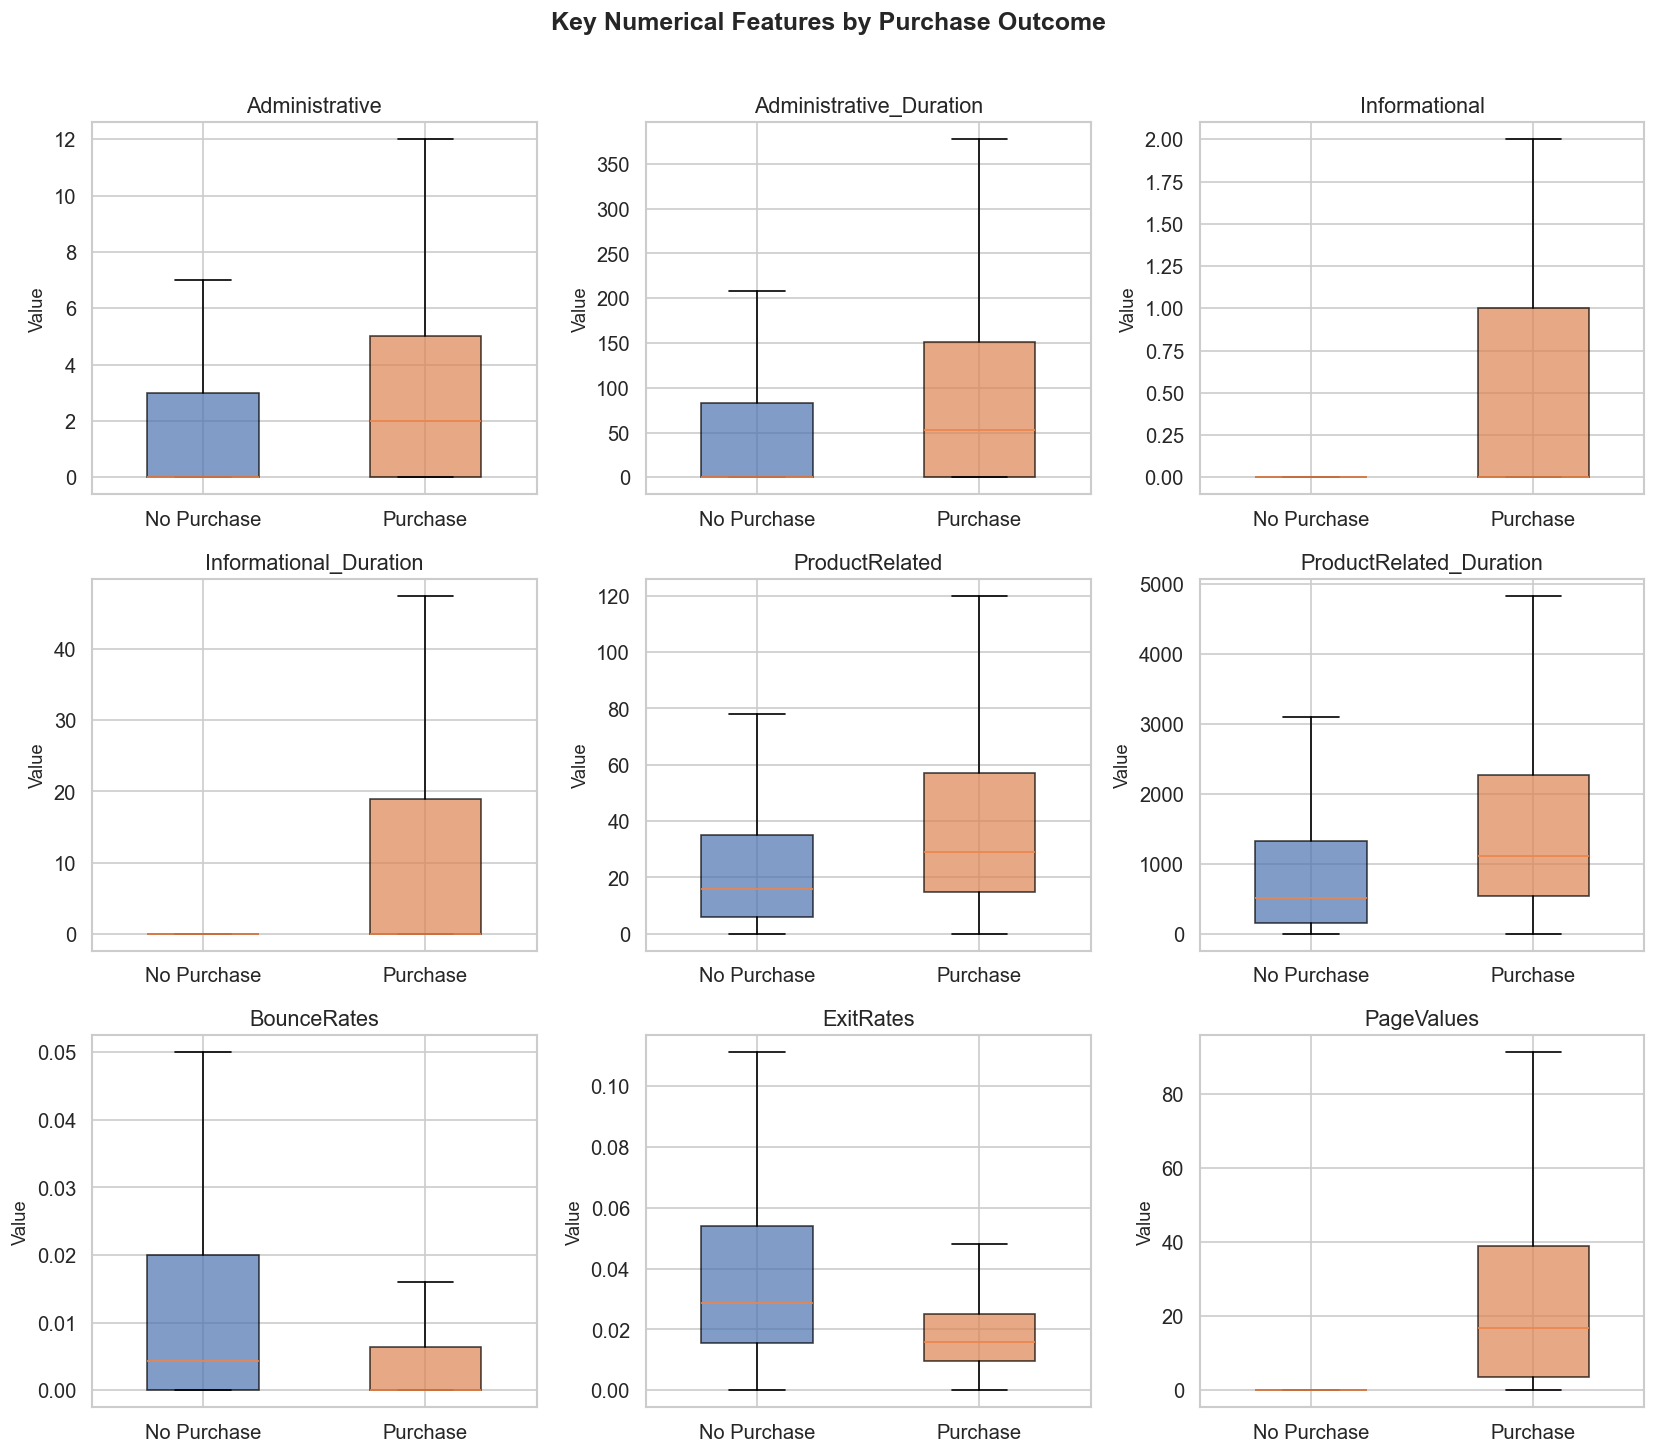

In [22]:
key_num = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
           'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data_f = df[df['Revenue'] == False][col]
    data_t = df[df['Revenue'] == True][col]
    bp = axes[i].boxplot([data_f, data_t], labels=['No Purchase', 'Purchase'],
                          patch_artist=True, widths=0.5, showfliers=False)
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Key Numerical Features by Purchase Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7.4 PageValues vs Revenue — Key Predictor Deep-Dive

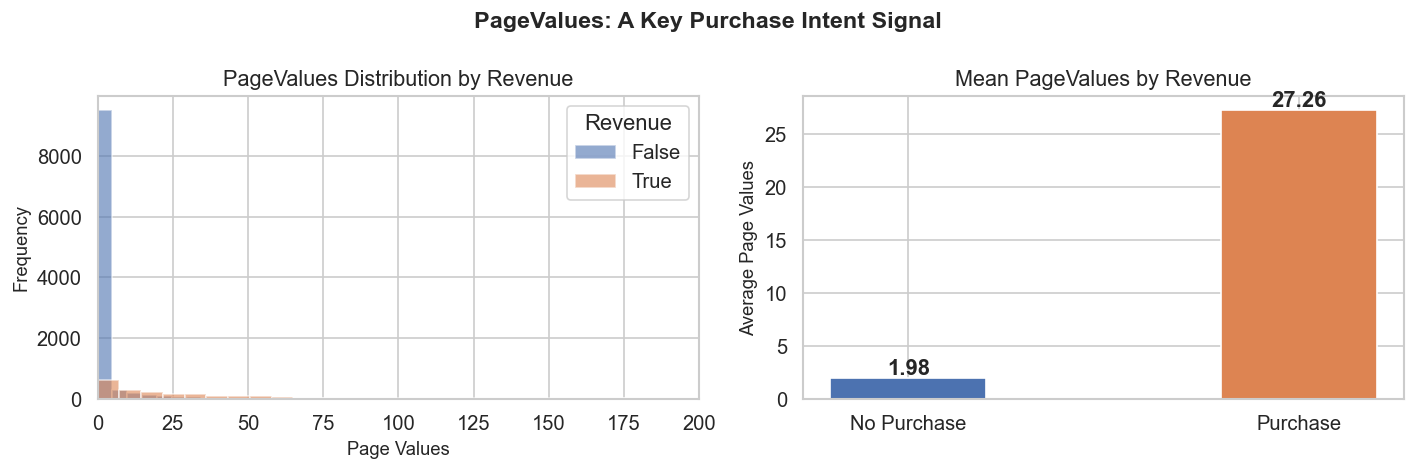

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(False, '#4C72B0'), (True, '#DD8452')]:
    subset = df[df['Revenue'] == label]['PageValues']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=str(label), edgecolor='white')
axes[0].set_title('PageValues Distribution by Revenue')
axes[0].set_xlabel('Page Values')
axes[0].set_ylabel('Frequency')
axes[0].legend(title='Revenue')
axes[0].set_xlim(0, 200)

avg_pv = df.groupby('Revenue')['PageValues'].mean()
axes[1].bar(['No Purchase', 'Purchase'], avg_pv.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(avg_pv.values):
    axes[1].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')
axes[1].set_title('Mean PageValues by Revenue')
axes[1].set_ylabel('Average Page Values')

plt.suptitle('PageValues: A Key Purchase Intent Signal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Multivariate Analysis

### 8.1 Correlation Heatmap (Numerical Features)

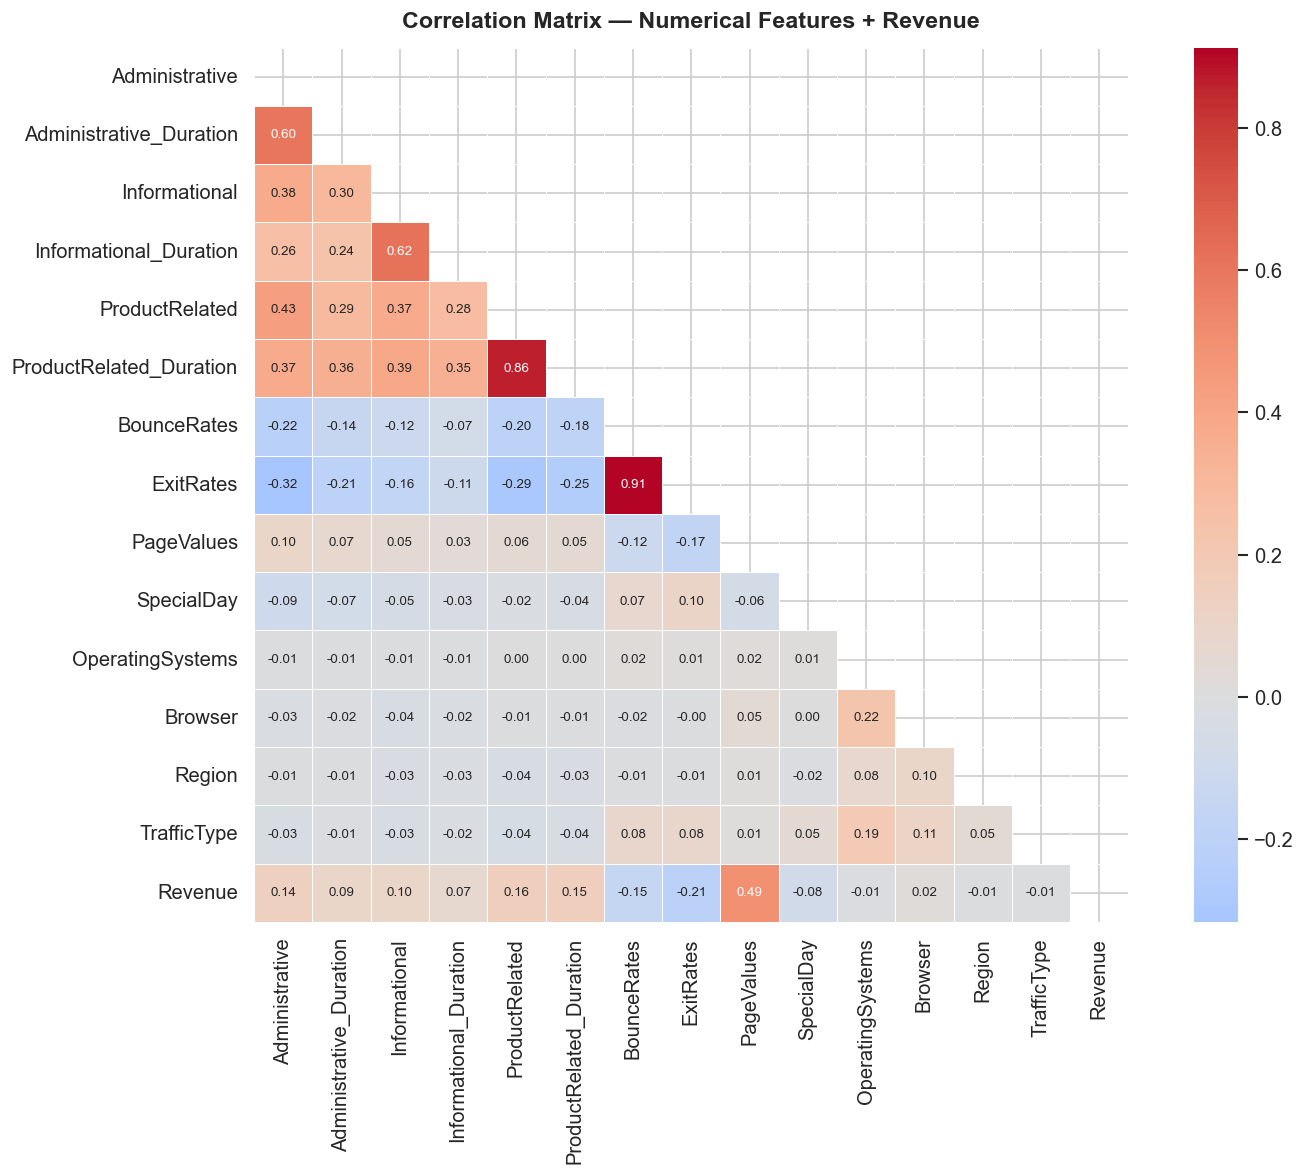

In [24]:
corr_df = df[num_cols].copy()
corr_df['Revenue'] = df['Revenue'].astype(int)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numerical Features + Revenue', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 8.2 Correlation with Target Variable (Revenue)

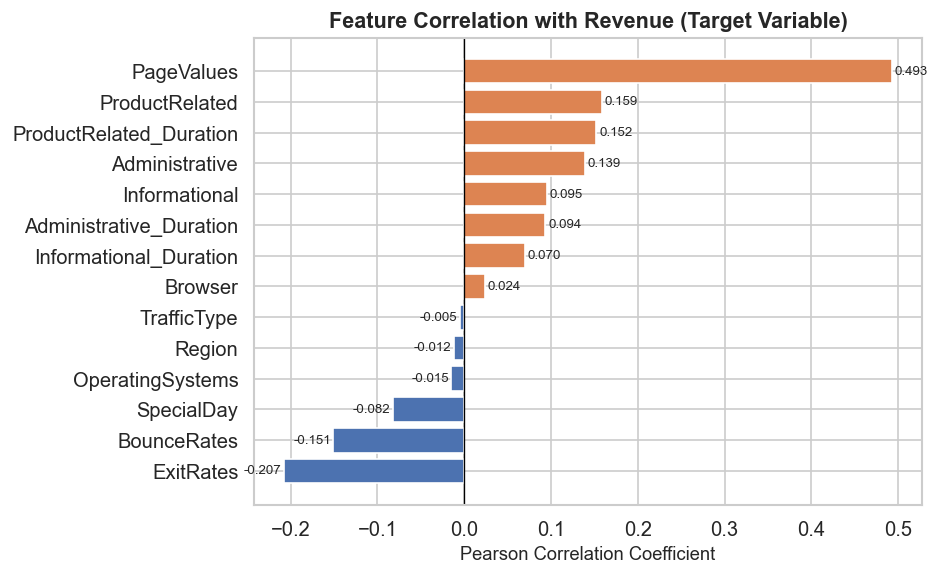

In [25]:
target_corr = corr_df.corr()['Revenue'].drop('Revenue').sort_values()

colors = ['#DD8452' if v > 0 else '#4C72B0' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Revenue (Target Variable)', fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, target_corr.values):
    xpos = val + 0.003 if val >= 0 else val - 0.003
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f'{val:.3f}', va='center', fontsize=8,
            ha='left' if val >= 0 else 'right')
plt.tight_layout()
plt.show()

### 8.3 Pairplot — Top Correlated Features

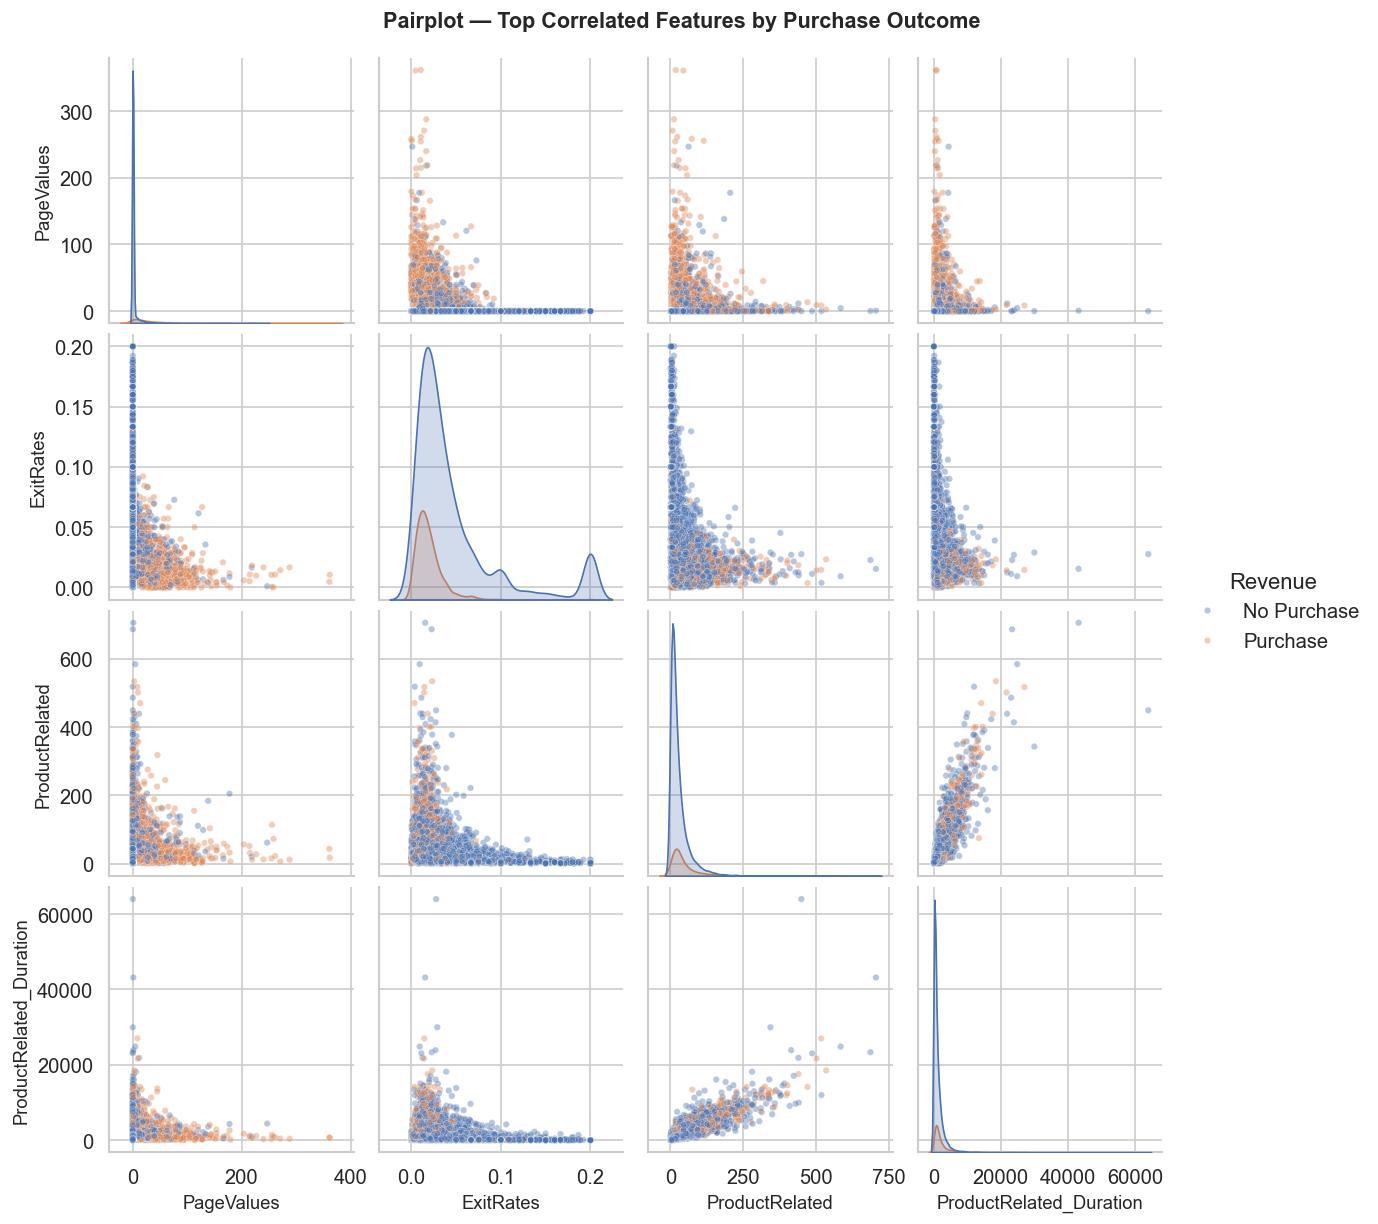

In [26]:
top_features = target_corr.abs().nlargest(4).index.tolist()
pair_df = df[top_features + ['Revenue']].copy()
pair_df['Revenue'] = pair_df['Revenue'].map({True: 'Purchase', False: 'No Purchase'})

g = sns.pairplot(pair_df, hue='Revenue', palette={'Purchase': '#DD8452', 'No Purchase': '#4C72B0'},
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pairplot — Top Correlated Features by Purchase Outcome', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### 8.4 BounceRates vs ExitRates by Revenue

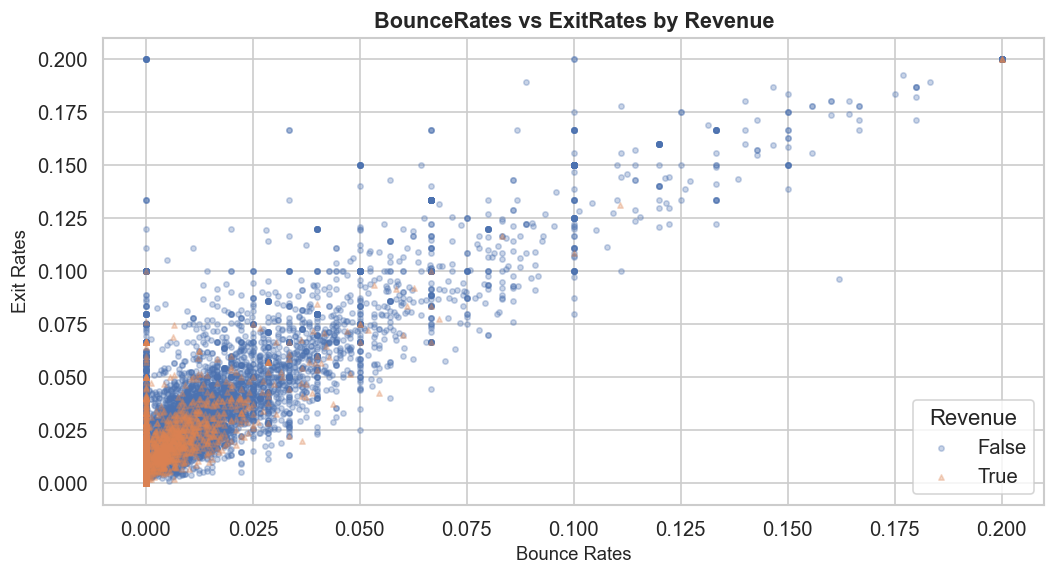

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, marker in [(False, '#4C72B0', 'o'), (True, '#DD8452', '^')]:
    subset = df[df['Revenue'] == label]
    ax.scatter(subset['BounceRates'], subset['ExitRates'], c=color, label=str(label),
               alpha=0.3, s=10, marker=marker)

ax.set_title('BounceRates vs ExitRates by Revenue', fontweight='bold')
ax.set_xlabel('Bounce Rates')
ax.set_ylabel('Exit Rates')
ax.legend(title='Revenue')
plt.tight_layout()
plt.show()

## 9. Outlier Detection

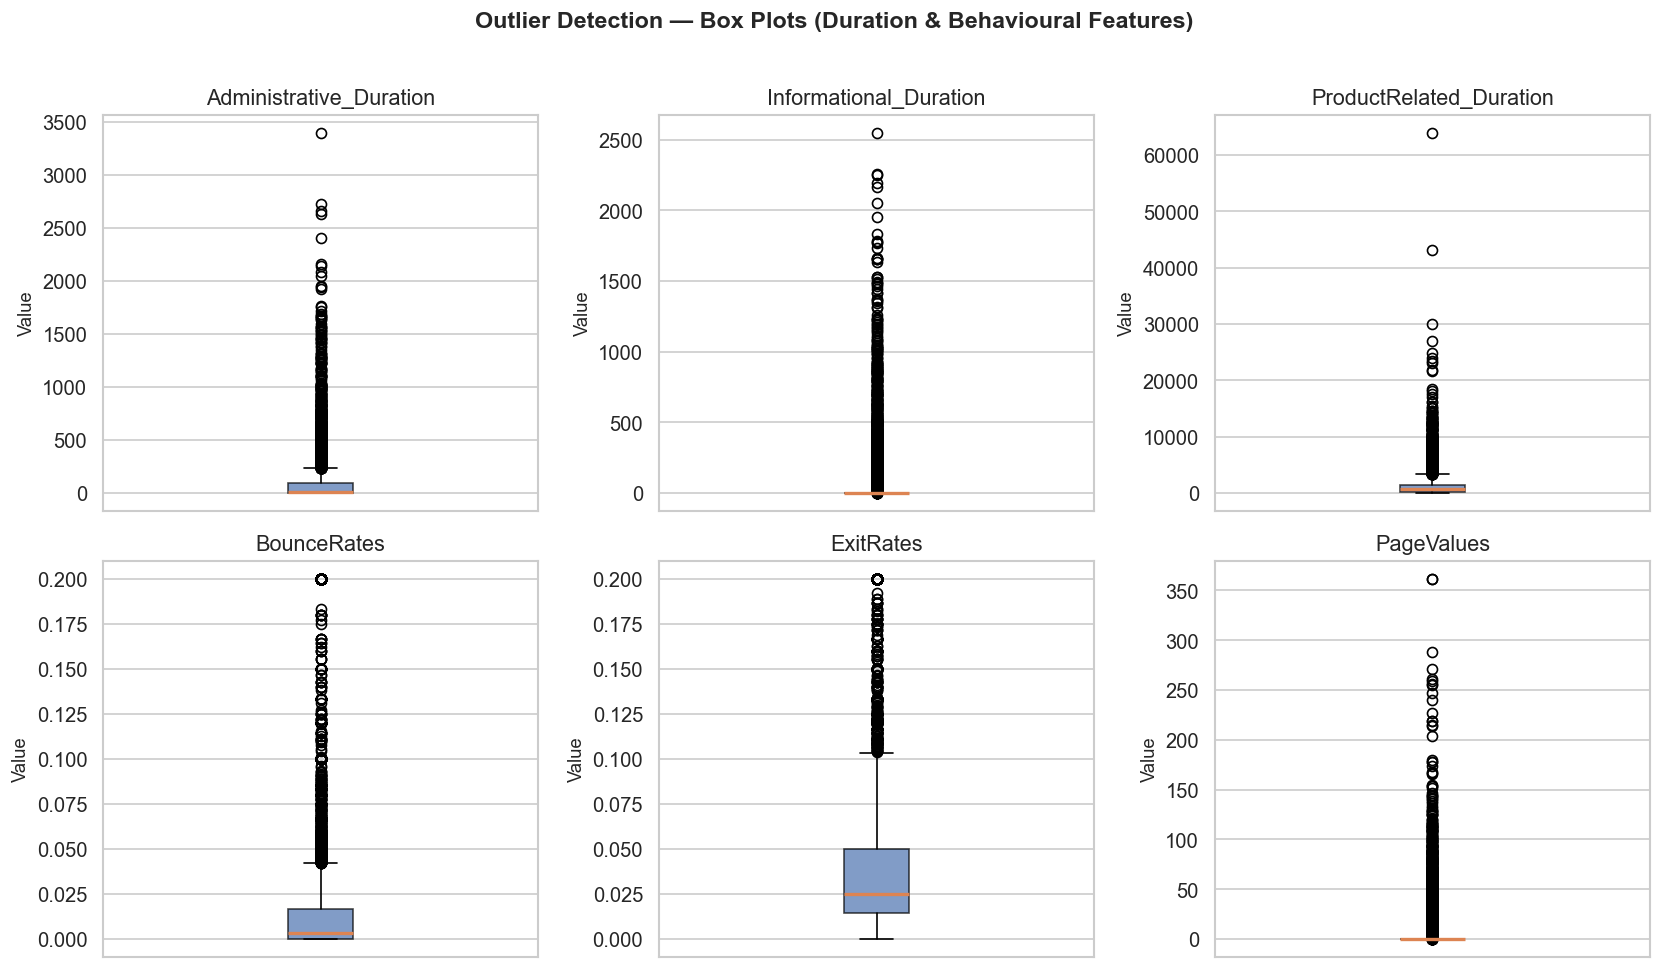

In [28]:
outlier_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
                'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.7),
                    medianprops=dict(color='#DD8452', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Outlier Detection — Box Plots (Duration & Behavioural Features)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [29]:
from scipy import stats

outlier_summary = []
for col in outlier_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_outliers = (z > 3).sum()
    pct = n_outliers / len(df) * 100
    outlier_summary.append({'Feature': col, 'Outliers (|z|>3)': n_outliers, 'Outlier %': round(pct, 2)})

pd.DataFrame(outlier_summary)

,Feature,Outliers (|z|>3),Outlier %
0,Administrative_Duration,232,1.88
1,Informational_Duration,230,1.87
2,ProductRelated_Duration,219,1.78
3,BounceRates,708,5.74
4,ExitRates,713,5.78
5,PageValues,259,2.10


## 10. Feature Engineering Insights

### 10.1 Session Intensity — Total Pages Visited

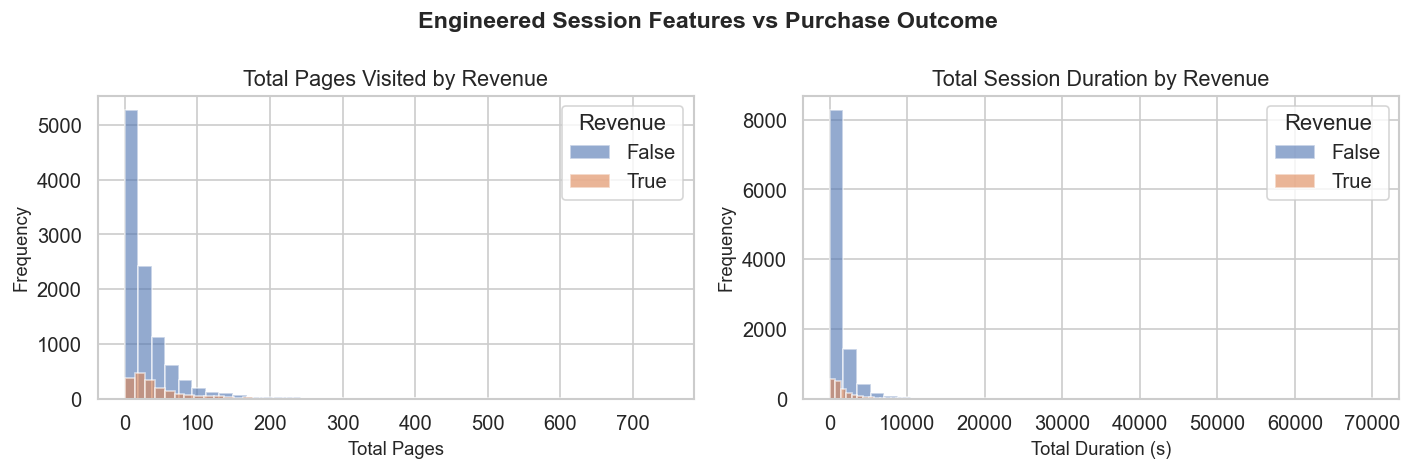

In [30]:
df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [(False, '#4C72B0'), (True, '#DD8452')]:
    subset = df[df['Revenue'] == label]
    axes[0].hist(subset['Total_Pages'], bins=40, alpha=0.6, color=color, label=str(label), edgecolor='white')
    axes[1].hist(subset['Total_Duration'], bins=40, alpha=0.6, color=color, label=str(label), edgecolor='white')

axes[0].set_title('Total Pages Visited by Revenue')
axes[0].set_xlabel('Total Pages')
axes[0].set_ylabel('Frequency')
axes[0].legend(title='Revenue')

axes[1].set_title('Total Session Duration by Revenue')
axes[1].set_xlabel('Total Duration (s)')
axes[1].set_ylabel('Frequency')
axes[1].legend(title='Revenue')

plt.suptitle('Engineered Session Features vs Purchase Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Product-Related Engagement Ratio

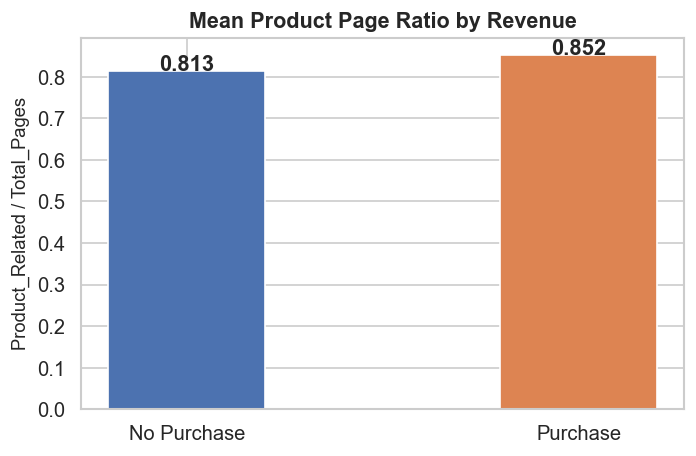

In [31]:
df['Product_Ratio'] = df['ProductRelated'] / (df['Total_Pages'] + 1)

avg_ratio = df.groupby('Revenue')['Product_Ratio'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Purchase', 'Purchase'], avg_ratio.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(avg_ratio.values):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')
ax.set_title('Mean Product Page Ratio by Revenue', fontweight='bold')
ax.set_ylabel('Product_Related / Total_Pages')
plt.tight_layout()
plt.show()

## 11. EDA Summary

In [32]:
summary = {
    'Total Sessions': len(df),
    'Purchase Sessions': int(df['Revenue'].sum()),
    'Non-Purchase Sessions': int((~df['Revenue']).sum()),
    'Purchase Rate (%)': round(df['Revenue'].mean() * 100, 2),
    'Total Features': df.shape[1],
    'Missing Values': int(df.isnull().sum().sum()),
    'Duplicate Rows': int(df.duplicated().sum()),
    'Numerical Features': len(num_cols),
    'Categorical Features': len(cat_cols),
    'Months Covered': df['Month'].nunique(),
    'Top Correlated Feature': target_corr.abs().idxmax()
}

summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df.index.name = 'Metric'
summary_df

,Value
Metric,
Total Sessions,12330
Purchase Sessions,1908
Non-Purchase Sessions,10422
Purchase Rate (%),15.47
Total Features,21
Missing Values,0
Duplicate Rows,125
Numerical Features,14
Categorical Features,3


## Step 12: Import Libraries

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import pandas as pd
import matplotlib.pyplot as plt

## Step 13: Prepare Features and Target

In [34]:
X = df.drop(columns=['Revenue'])
y = df['Revenue'].astype(int)

## Step 14: Identify Categorical and Numerical Columns

In [35]:
categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features, numerical_features

(['Month', 'VisitorType', 'Weekend'],
 ['Administrative',
  'Administrative_Duration',
  'Informational',
  'Informational_Duration',
  'ProductRelated',
  'ProductRelated_Duration',
  'BounceRates',
  'ExitRates',
  'PageValues',
  'SpecialDay',
  'OperatingSystems',
  'Browser',
  'Region',
  'TrafficType',
  'Total_Pages',
  'Total_Duration',
  'Product_Ratio'])

## Step 15: Split Data into Training and Testing Sets

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((9864, 20), (2466, 20))

## Step 16: Create Preprocessor

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

## Step 17: Create Random Forest Model

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

## Step 18: Create Model Pipeline

In [39]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

## Step 19: Train the Model

In [40]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Step 20: Make Predictions

In [41]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

## Step 21: Model Performance Results

In [42]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

model_results = pd.DataFrame({
    'Model': ['Random Forest Classifier'],
    'Accuracy': [round(accuracy, 4)],
    'Precision': [round(precision, 4)],
    'Recall': [round(recall, 4)],
    'F1-Score': [round(f1, 4)],
    'ROC-AUC': [round(roc_auc, 4)]
})

model_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest Classifier,0.882,0.5974,0.7304,0.6572,0.9194


## Step 22: Classification Report

In [43]:
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

              precision    recall  f1-score   support

 No Purchase       0.95      0.91      0.93      2084
    Purchase       0.60      0.73      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77      0.82      0.79      2466
weighted avg       0.89      0.88      0.89      2466



## Step 23: Confusion Matrix

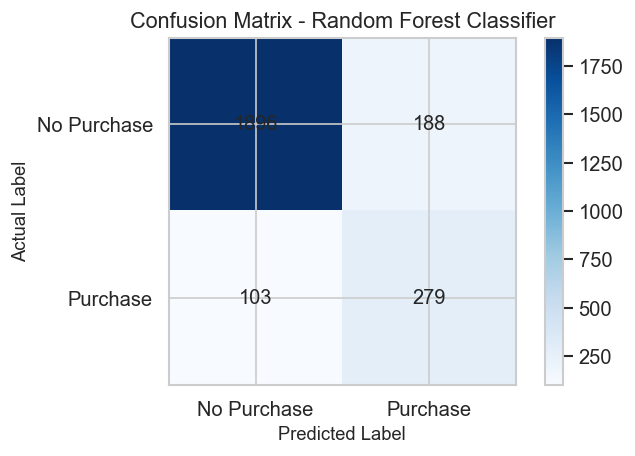

In [44]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0, 1], ['No Purchase', 'Purchase'])
plt.yticks([0, 1], ['No Purchase', 'Purchase'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()

## Step 24: ROC Curve

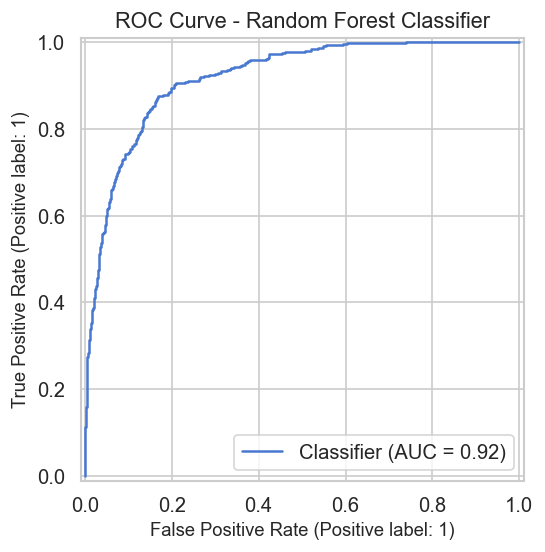

In [45]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title('ROC Curve - Random Forest Classifier')
plt.tight_layout()
plt.show()

## Step 25: Feature Importance

In [46]:
encoded_cat_features = model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

all_feature_names = list(encoded_cat_features) + numerical_features

feature_importance = model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

importance_df.head(15)

,Feature,Importance
23,PageValues,0.431065
22,ExitRates,0.077008
20,ProductRelated_Duration,0.059584
30,Total_Duration,0.059556
21,BounceRates,0.046104
29,Total_Pages,0.038258
19,ProductRelated,0.037991
31,Product_Ratio,0.033288
16,Administrative_Duration,0.032783
7,Month_Nov,0.029574


## Step 26: Feature Importance Chart

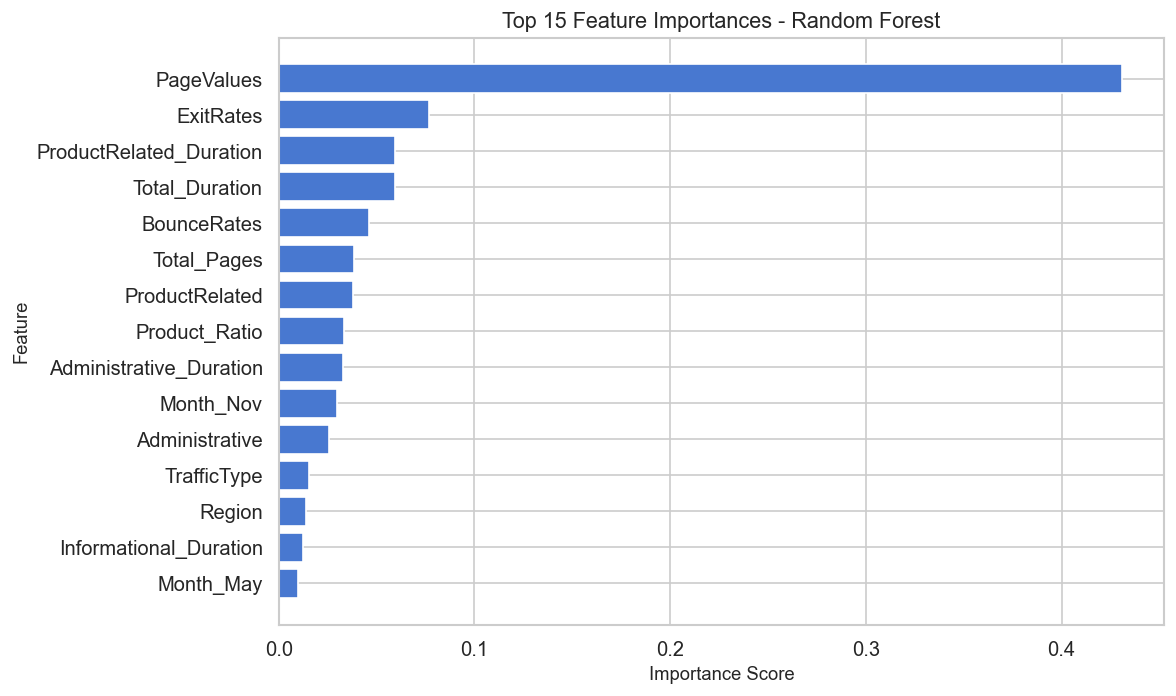

In [47]:
top_15 = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15['Feature'][::-1], top_15['Importance'][::-1])
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()